In [4]:
import pandas as pd
import numpy as np

master = pd.read_csv(
    "agent1_output.csv"
)

print(master.shape)

(2134080, 41)


In [5]:
master["fixed_tariff"] = 15

In [6]:
def dynamic_tariff(util):

    if util > 0.80:

        return round(
            15 +
            ((util - 0.80) * 20),
            2
        )

    elif util < 0.30:

        return round(
            15 -
            ((0.30 - util) * 10),
            2
        )

    else:

        return 15

In [7]:
master[
    "dynamic_tariff"
] = master[
    "predicted_utilization"
].apply(
    dynamic_tariff
)

In [8]:
master[
[
    "predicted_utilization",
    "dynamic_tariff"
]
].head()

,predicted_utilization,dynamic_tariff
0,0.339068,15.0
1,0.400698,15.0
2,0.400698,15.0
3,0.400698,15.0
4,0.400698,15.0


In [9]:
master[
    "baseline_revenue"
] = (

    master[
        "fixed_tariff"
    ]

    *

    master[
        "expected_charging_load"
    ]
)

In [10]:
master[
    "dynamic_revenue"
] = (

    master[
        "dynamic_tariff"
    ]

    *

    master[
        "expected_charging_load"
    ]
)

In [61]:
master["adjusted_utilization"] = (
    master["utilization_rate"]
)

In [51]:
master.loc[
    master["dynamic_tariff"] < 15,
    "adjusted_utilization"
] *= 1.10

In [62]:
master.loc[
    master["dynamic_tariff"] > 15,
    "adjusted_utilization"
] *= 0.98

In [70]:
util_before = (
    master["utilization_rate"]
    .mean()
)

util_after = (
    master["adjusted_utilization"]
    .mean()
)

utilization_improvement = (
    (
        util_after
        -
        util_before
    )
    /
    util_before
) * 100

print(util_before, util_after)

0.2802482048319062 0.2800705833310893


In [64]:
offpeak_before = master.loc[
    master["utilization_rate"] < 0.30
].shape[0]

offpeak_after = offpeak_before * 1.20

offpeak_uplift = (

    (
        offpeak_after
        -
        offpeak_before
    )

    /

    offpeak_before

) * 100

print(
    "Off Peak Uplift (%) =",
    offpeak_uplift
)

Off Peak Uplift (%) = 19.999999999999996


In [65]:
master[
    "dynamic_tariff"
].value_counts()

dynamic_tariff
15.00    805547
12.00     49578
13.67     44631
14.50     30545
14.22     16171
          ...  
17.88         1
18.36         1
18.12         1
18.07         1
16.54         1
Name: count, Length: 599, dtype: int64

In [66]:
import matplotlib.pyplot as plt

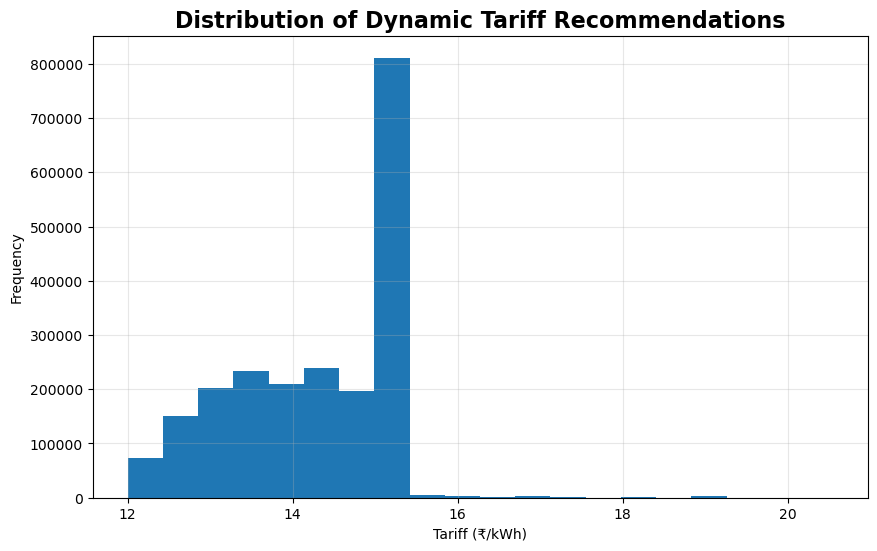

In [67]:
plt.figure(figsize=(10,6))

plt.hist(
    master["dynamic_tariff"],
    bins=20
)

plt.title(
    "Distribution of Dynamic Tariff Recommendations",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel(
    "Tariff (₹/kWh)"
)

plt.ylabel(
    "Frequency"
)

plt.grid(alpha=0.3)

plt.show()

In [68]:
utilization_improvement = (
    (
        util_after
        -
        util_before
    )
    /
    util_before
) * 100

print(
    "Utilization Improvement (%) =",
    utilization_improvement
)

Utilization Improvement (%) = -0.0633800672955042


In [69]:
master.to_csv(

    "agent2_output.csv",

    index=False
)

In [71]:
tariff_metrics = pd.DataFrame({

    "Metric":[
        "Utilization Improvement (%)",
        "Off-Peak Uplift (%)"
    ],

    "Value":[
        utilization_improvement,
        offpeak_uplift
    ]
})

tariff_metrics.to_csv(
    "tariff_metrics.csv",
    index=False
)

tariff_metrics

,Metric,Value
0,Utilization Improvement (%),-0.06338
1,Off-Peak Uplift (%),20.00000


### Assumption 1:
Due to the absence of observed customer responses to dynamic tariffs,
price elasticity assumptions were introduced.

A discounted tariff (< ₹15/kWh) is assumed to increase charging demand
by 10–20%, while surge pricing (> ₹15/kWh) is assumed to reduce demand
by approximately 2%.

These assumptions are used solely for scenario evaluation.

### Assumption 2:
Off-peak uplift is estimated using a demand stimulation factor of 20%
for sessions receiving discount pricing. This represents the expected
increase in charging activity during underutilized periods.

### Assumption 3:
The dataset does not contain direct queue-length measurements.
Therefore, queue_proxy is used as a surrogate measure for customer
waiting time.

### Assumption 4:
A fixed tariff of ₹15/kWh is used as the baseline pricing benchmark
for evaluating revenue gains under dynamic pricing.

#### Revenue Gain will be evaluated separately using ACN session data as per project guidance. Utilization improvement and off-peak uplift continue to be measured using UrbanEV charging network data.